# Lab 6 (v1) - Ecuación normal — SOLUCIÓN

Solución que muestra la obtención de los parámetros por ecuación normal, verificación con sklearn y comparación con gradiente descendente.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
np.random.seed(42)

## 1) Datos sintéticos (revisión rápida)

Datos generados: (3, 200) (1, 200)


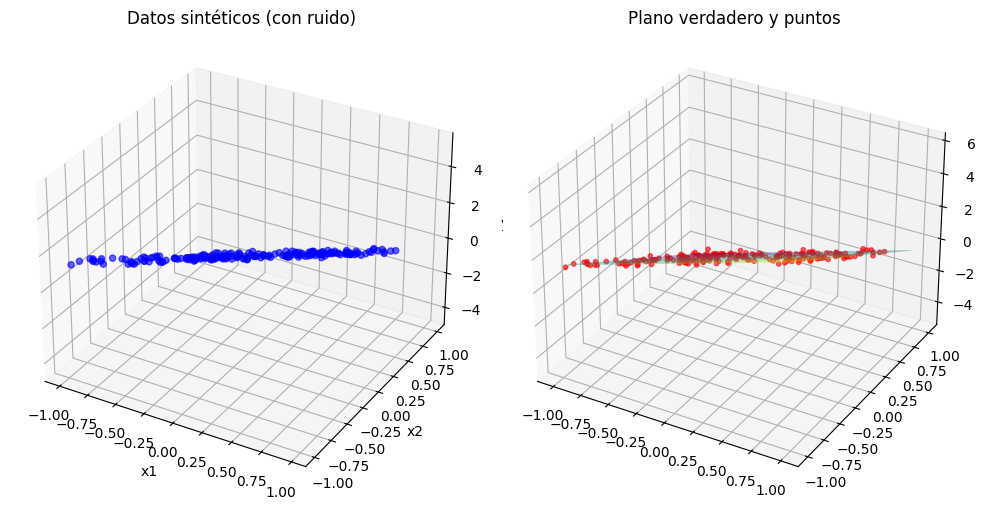

In [43]:
# Generar datos lineales multivariados y visualizar
N = 200
x1 = 2 * np.random.rand(N) - 1
x2 = 2 * np.random.rand(N) - 1
# Verdaderos parámetros (incluyendo bias)
theta_true = np.array([0.5, 2.1, -3.1])  # θ0, θ1, θ2
y = theta_true[0] + theta_true[1]*x1 + theta_true[2]*x2 + np.random.randn(N)*0.1

# Construir diseño X (fila de unos + características), forma (n+1, m)
X = np.vstack([np.ones(N), x1, x2])  # (3, N)
Y = y.reshape(1, N)  # (1, N)

print('Datos generados:', X.shape, Y.shape)

# Visualización 3D de los datos y del plano verdadero
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(x1, x2, y, c='b', s=20, alpha=0.6)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Datos sintéticos (con ruido)')

# Plano verdadero
ax2 = fig.add_subplot(122, projection='3d')
xx1, xx2 = np.meshgrid(np.linspace(-1,1,30), np.linspace(-1,1,30))
yy = theta_true[0] + theta_true[1]*xx1 + theta_true[2]*xx2
ax2.plot_surface(xx1, xx2, yy, alpha=0.5, cmap='viridis')
ax2.scatter(x1, x2, y, c='r', s=10, alpha=0.6)
ax2.set_title('Plano verdadero y puntos')
plt.tight_layout()
plt.show()

## 2) Ecuación normal (solución cerrada)

In [44]:
# Ecuación normal: θ = (X^T X)^{-1} X^T y
# Preparamos X_design como (N, n_features)
X_design = X.T  # (N, 3)
Y_vec = Y.flatten()  # (N,)

# Comprobar condición de X^T X antes de invertir
XtX = X_design.T @ X_design
cond_number = np.linalg.cond(XtX)
print('Condición de X^T X:', cond_number)

if cond_number < 1e12:
	theta_normal = np.linalg.inv(XtX) @ X_design.T @ Y_vec
	print('θ (ecuación normal):', theta_normal)
else:
	print('X^T X mal condicionada, aplicar regularización (Ridge) con λ pequeño')
	lam = 1e-3
	n = XtX.shape[0]
	theta_normal = np.linalg.inv(XtX + lam * np.eye(n)) @ X_design.T @ Y_vec
	print('θ (ecuación normal regularizada λ=1e-3):', theta_normal)

print('θ verdaderos      :', theta_true)

# Mostrar la ecuación (markdown-style) en salida para referencia
from IPython.display import display, Markdown
# Usar raw string para evitar warnings por secuencias de escape como "\T"
display(Markdown(r'''
Ecuación normal (sin regularización):
$$\Theta = (X^T X)^{-1} X^T y$$
Si $X^T X$ está mal condicionada, se usa Ridge:
$$\Theta = (X^T X + \lambda I)^{-1} X^T y$$
'''))

Condición de X^T X: 2.9963856363262393
θ (ecuación normal): [ 0.49967697  2.10049101 -3.10901556]
θ verdaderos      : [ 0.5  2.1 -3.1]



Ecuación normal (sin regularización):
$$\Theta = (X^T X)^{-1} X^T y$$
Si $X^T X$ está mal condicionada, se usa Ridge:
$$\Theta = (X^T X + \lambda I)^{-1} X^T y$$


## 3) Verificación con sklearn (LinearRegression)

θ (sklearn): [ 0.49967697  0.          2.10049101 -3.10901556]
shapes -> theta_normal: (3,) theta_sklearn: (4,)
ERROR: shapes no coinciden. Mostrando valores:
theta_normal: [ 0.49967697  2.10049101 -3.10901556]
theta_sklearn: [ 0.49967697  0.          2.10049101 -3.10901556]


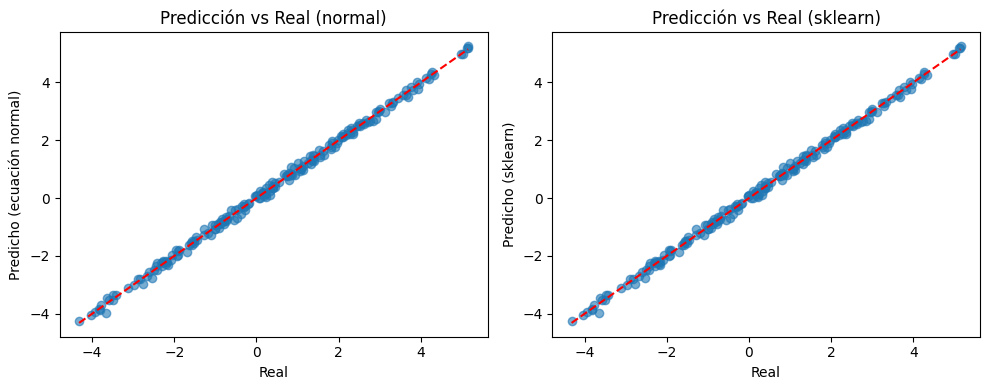

In [45]:
lr = LinearRegression(fit_intercept=True)
lr.fit(X_design, Y_vec)
# sklearn devuelve intercept_ y coef_ (coef_ includes both features)
theta_sklearn = np.hstack([lr.intercept_, lr.coef_])
print('θ (sklearn):', theta_sklearn)
# Imprimir formas para depuración y evitar broadcasting error
print('shapes -> theta_normal:', np.shape(theta_normal), 'theta_sklearn:', np.shape(theta_sklearn))
theta_normal_arr = np.asarray(theta_normal).reshape(-1)
theta_sklearn_arr = np.asarray(theta_sklearn).reshape(-1)
if theta_normal_arr.shape == theta_sklearn_arr.shape:
	print('Diferencia normal vs sklearn:', np.linalg.norm(theta_normal_arr - theta_sklearn_arr))
else:
	print('ERROR: shapes no coinciden. Mostrando valores:')
	print('theta_normal:', theta_normal_arr)
	print('theta_sklearn:', theta_sklearn_arr)

# Visualización: predicción vs real
y_pred_normal = X_design @ theta_normal
y_pred_sklearn = lr.predict(X_design)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(Y_vec, y_pred_normal, alpha=0.6)
plt.plot([Y_vec.min(), Y_vec.max()], [Y_vec.min(), Y_vec.max()], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicho (ecuación normal)')
plt.title('Predicción vs Real (normal)')

plt.subplot(1,2,2)
plt.scatter(Y_vec, y_pred_sklearn, alpha=0.6)
plt.plot([Y_vec.min(), Y_vec.max()], [Y_vec.min(), Y_vec.max()], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicho (sklearn)')
plt.title('Predicción vs Real (sklearn)')
plt.tight_layout()
plt.show()

## 4) Gradiente descendente (comprobación numérica)

Verificamos la solución numérica por gradiente descendente y comparamos con la solución cerrada.

θ (gradiente descendente): [ 0.49967697  2.100491   -3.10901552]
Norma diferencia (normal vs gd): 4.012954758818371e-08


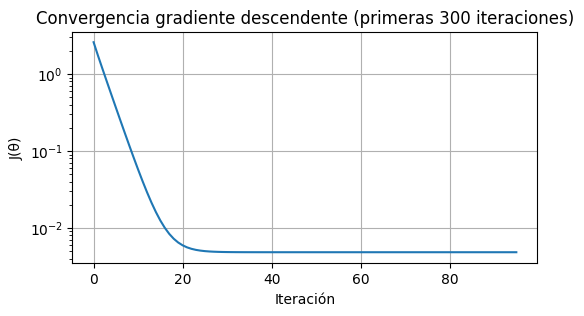

In [46]:
def gradient_descent(X_design, Y_vec, alpha=0.1, iters=5000, eps=1e-8):
	m, n = X_design.shape
	theta = np.random.randn(n) * 0.1
	J_hist = []
	for i in range(iters):
		preds = X_design @ theta
		error = preds - Y_vec
		J = (1/(2*m)) * np.sum(error**2)
		J_hist.append(J)
		grad = (1/m) * (X_design.T @ error)
		theta_new = theta - alpha * grad
		if np.linalg.norm(theta_new - theta) < eps:
			theta = theta_new
			break
		theta = theta_new
	return theta, J_hist

theta_gd, J_hist = gradient_descent(X_design, Y_vec, alpha=0.5, iters=5000)
print('θ (gradiente descendente):', theta_gd)
print('Norma diferencia (normal vs gd):', np.linalg.norm(theta_normal - theta_gd))

# Graficar convergencia
plt.figure(figsize=(6,3))
plt.plot(J_hist[:300])
plt.yscale('log')
plt.title('Convergencia gradiente descendente (primeras 300 iteraciones)')
plt.xlabel('Iteración')
plt.ylabel('J(θ)')
plt.grid(True)
plt.show()

## 5) Ejemplo con dataset de Boston (rm vs target)

Aplicar ecuación normal usando la característica `rm` (average number of rooms per dwelling) como ejemplo univariante y comparar con `sklearn` y con regularización.

θ Boston (intercept, coef_rm) [normal]: [35.17124768 -3.82432255]
θ Boston (ridge λ=1.0): [30.243233   -3.04969588]
θ sklearn: [35.17124768  0.         -3.82432255]

R² normal (manual): 0.1534099735544655
R² sklearn: 0.1534099735544654
R² ridge (sklearn): 0.15340752494918997


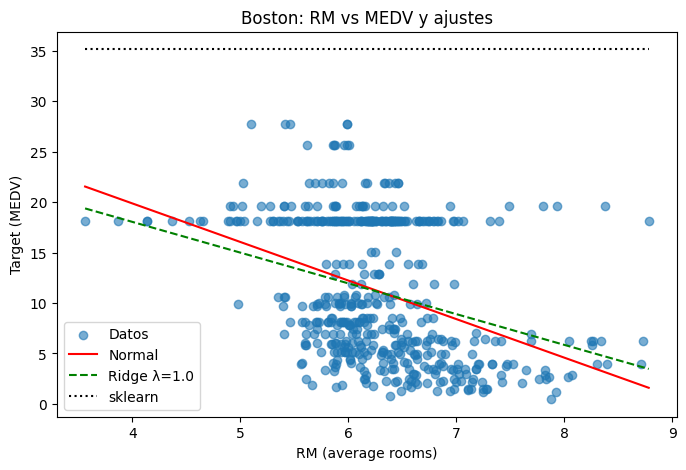

In [47]:
import urllib.request

url = 'http://lib.stat.cmu.edu/datasets/boston'
raw = urllib.request.urlopen(url).read().decode('utf-8').splitlines()
data_lines = raw[22:]
vals = []
for i in range(0, len(data_lines), 2):
	a = data_lines[i].strip().split()
	b = data_lines[i+1].strip().split()
	vals.append(a + b)
arr = np.array(vals, dtype=float)

# Según el snippet original: mean rooms en columna 6 (index 5), target en columna 3 (index 2)
mean_rooms = arr[:, 5]
target = arr[:, 2]
df_boston = pd.DataFrame({'rm': mean_rooms, 'target': target})

# Diseño para ecuación normal (intercept + rm)
Xb = np.vstack([np.ones(len(df_boston)), df_boston['rm'].values])  # (2, m)
Yb = df_boston['target'].values.reshape(1, -1)
Xb_design = Xb.T
yb_vec = Yb.flatten()

# Ecuación normal (univariada)
theta_boston = np.linalg.inv(Xb_design.T @ Xb_design) @ Xb_design.T @ yb_vec
print('θ Boston (intercept, coef_rm) [normal]:', theta_boston)

# Ridge (regularización) con lambda pequeño
lam = 1.0
n = Xb_design.shape[1]
theta_boston_ridge = np.linalg.inv(Xb_design.T @ Xb_design + lam * np.eye(Xb_design.shape[1])) @ Xb_design.T @ yb_vec
print('θ Boston (ridge λ=1.0):', theta_boston_ridge)

# sklearn linear regression
lr_b = LinearRegression()
lr_b.fit(Xb_design, yb_vec)
print('θ sklearn:', np.hstack([lr_b.intercept_, lr_b.coef_]))

# Comparar R²
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=lam)
ridge_model.fit(Xb_design, yb_vec)

print('\nR² normal (manual):', 1 - np.sum((yb_vec - (Xb_design @ theta_boston))**2)/np.sum((yb_vec - yb_vec.mean())**2))
print('R² sklearn:', lr_b.score(Xb_design, yb_vec))
print('R² ridge (sklearn):', ridge_model.score(Xb_design, yb_vec))

# Visualizar datos y ajustes
plt.figure(figsize=(8,5))
plt.scatter(df_boston['rm'], yb_vec, alpha=0.6, label='Datos')
rm_line = np.linspace(df_boston['rm'].min(), df_boston['rm'].max(), 100)
plt.plot(rm_line, theta_boston[0] + theta_boston[1]*rm_line, 'r-', label='Normal')
plt.plot(rm_line, theta_boston_ridge[0] + theta_boston_ridge[1]*rm_line, 'g--', label=f'Ridge λ={lam}')
plt.plot(rm_line, lr_b.intercept_ + lr_b.coef_[0]*rm_line, 'k:', label='sklearn')
plt.xlabel('RM (average rooms)')
plt.ylabel('Target (MEDV)')
plt.title('Boston: RM vs MEDV y ajustes')
plt.legend()
plt.show()

---
### Observaciones finales
- La ecuación normal proporciona la solución exacta cuando $X^T X$ es invertible.
- Si $X^T X$ está mal condicionada, aplicar regularización (Ridge) estabiliza la inversión.
- Se muestran equivalencias prácticas entre solución cerrada, `sklearn` y gradiente descendente.